Промпт:
```
Ты — Data Scientist. Мне нужно создать Python-приложение в формате Jupyter Notebook для классификации сетевого трафика на нормальный (Normal) и вредоносный (DDoS). 

Входные данные:
Датасет содержит следующие признаки: Unnamed: 0, pkSeqID, stime, flgs, flgs_number, proto, proto_number, saddr, sport, daddr, dport, pkts, bytes, state, state_number, ltime, seq, dur, mean, stddev, sum, min, max, spkts, dpkts, sbytes, dbytes, rate, srate, drate, TnBPSrcIP, TnBPDstIP, TnP_PSrcIP, TnP_PDstIP, TnP_PerProto, TnP_Per_Dport, AR_P_Proto_P_SrcIP, AR_P_Proto_P_DstIP, N_IN_Conn_P_DstIP, N_IN_Conn_P_SrcIP, AR_P_Proto_P_Sport, AR_P_Proto_P_Dport, Pkts_P_State_P_Protocol_P_DestIP, Pkts_P_State_P_Protocol_P_SrcIP, attack, category, subcategory.

Целевая переменная: 'category' (принимает значения 'DDoS' или 'Normal'). В датасете присутствует критический дисбаланс классов: около 2 000 000 записей DDoS и всего около 500 записей Normal.

Твоя задача — предложить решение и написать код, разбив его на логические блоки (ячейки Jupyter Notebook):

1. Загрузка и первичный анализ данных: выведи размеры, визуализируй дисбаланс классов.
2. Предобработка данных: подготовь признаки к обучению. Самостоятельно реши, какие признаки нужно удалить, чтобы избежать переобучения и утечки данных, как закодировать категориальные переменные и масштабировать числовые.
3. Обработка дисбаланса классов: предложи и реализуй наиболее эффективный метод борьбы с сильным перекосом данных (учитывай риски нехватки оперативной памяти при работе с 2 млн строк).
4. Обучение моделей: выбери и обучи минимум две подходящие для этой задачи модели машинного обучения.
5. Оценка результатов: выведи отчеты по метрикам и визуализируй матрицы ошибок (Confusion Matrix) для каждой модели. Напиши краткий вывод, какая модель справилась лучше и почему.

Код должен быть воспроизводимым, с комментариями на русском языке к каждому шагу.
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('DDoSdata.csv')  # Замените на путь к вашему датасету

print("Размеры датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())


Размеры датасета: (1927101, 47)

Первые 5 строк:
   Unnamed: 0  pkSeqID         stime flgs  flgs_number proto  proto_number  \
0     1650261  1650261  1.528103e+09    e            1   tcp             1   
1     1650262  1650262  1.528103e+09    e            1   tcp             1   
2     1650263  1650263  1.528103e+09    e            1   tcp             1   
3     1650264  1650264  1.528103e+09    e            1   tcp             1   
4     1650265  1650265  1.528103e+09    e            1   tcp             1   

             saddr  sport          daddr  ... AR_P_Proto_P_DstIP  \
0  192.168.100.150  54110  192.168.100.3  ...            1.21662   
1  192.168.100.150  54112  192.168.100.3  ...            1.21662   
2  192.168.100.150  54114  192.168.100.3  ...            1.21662   
3  192.168.100.150  54116  192.168.100.3  ...            1.21662   
4  192.168.100.150  54118  192.168.100.3  ...            1.21662   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP AR_P_Proto_P_Sport  \
0          

Распределение классов:
category
DDoS      1926624
Normal        477
Name: count, dtype: int64


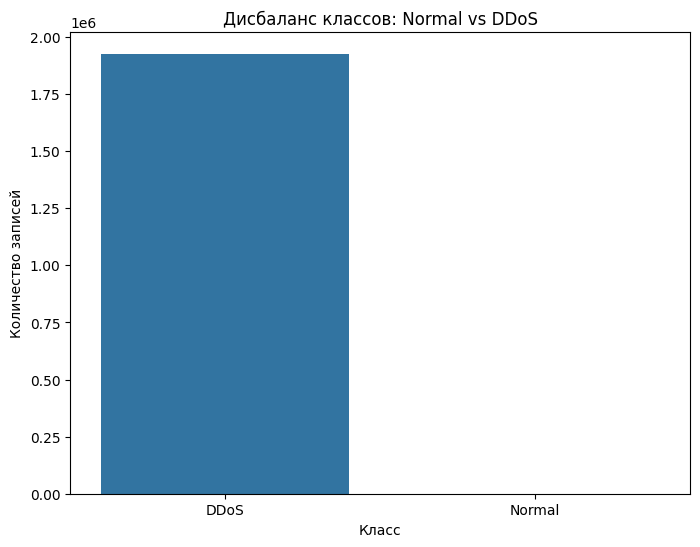


Процент DDoS: 99.98%
Процент Normal: 0.02%


In [3]:
# Проверка распределения целевой переменной
class_counts = df['category'].value_counts()
print("Распределение классов:")
print(class_counts)

# Визуализация дисбаланса
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='category')
plt.title('Дисбаланс классов: Normal vs DDoS')
plt.xlabel('Класс')
plt.ylabel('Количество записей')
plt.show()

# Процентное соотношение
print(f"\nПроцент DDoS: {class_counts['DDoS'] / len(df) * 100:.2f}%")
print(f"Процент Normal: {class_counts['Normal'] / len(df) * 100:.2f}%")


In [5]:
# Удаление ненужных признаков (идентификаторы, временные метки, дублирующие признаки)
columns_to_drop = ['Unnamed: 0', 'pkSeqID', 'stime', 'saddr', 'daddr',
                    'ltime', 'seq', 'flgs', 'proto', 'state']
df_clean = df.drop(columns=columns_to_drop)

print(f"Удалено {len(columns_to_drop)} признаков. Новые размеры: {df_clean.shape}")

# Кодирование категориальных переменных (если остались)
categorical_columns = df_clean.select_dtypes(include=['object']).columns
categorical_columns = categorical_columns.drop('category')  # Исключаем целевую переменную

# Принудительно переводим все значения этих колонок в строки
df_clean[categorical_columns] = df_clean[categorical_columns].astype(str)

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Разделение на признаки и целевую переменную
X = df_clean.drop('category', axis=1)
y = df_clean['category']

# Масштабирование числовых признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Предобработка завершена.")


Удалено 10 признаков. Новые размеры: (1927101, 37)
Предобработка завершена.


Размеры после undersampling: (954, 36)
Распределение классов после undersampling:
category
DDoS      477
Normal    477
Name: count, dtype: int64


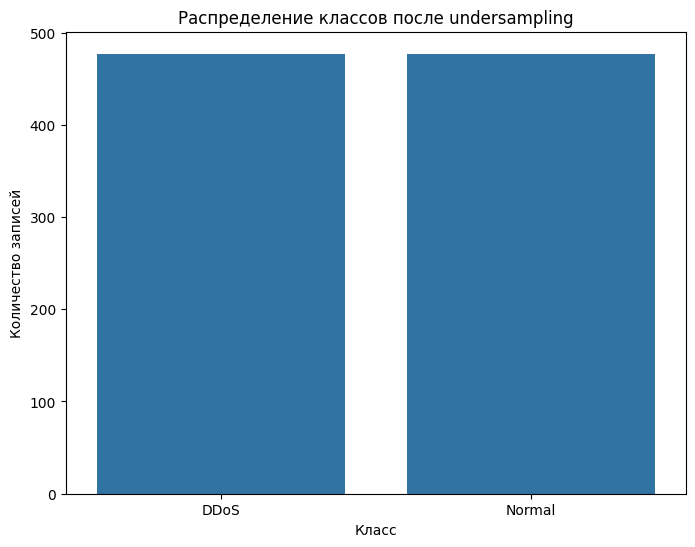

In [6]:
# Используем undersampling для DDoS, чтобы избежать проблем с памятью
undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_scaled, y)

print(f"Размеры после undersampling: {X_resampled.shape}")
print(f"Распределение классов после undersampling:")
print(y_resampled.value_counts())

# Визуализация после балансировки
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Распределение классов после undersampling')
plt.xlabel('Класс')
plt.ylabel('Количество записей')
plt.show()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")


Обучающая выборка: 763 записей
Тестовая выборка: 191 записей


In [8]:
# Модель 1: Логистическая регрессия
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Модель 2: Случайный лес
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Модели обучены.")


Модели обучены.



=== Логистическая регрессия ===
Отчет по метрикам:
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00        96
      Normal       1.00      1.00      1.00        95

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



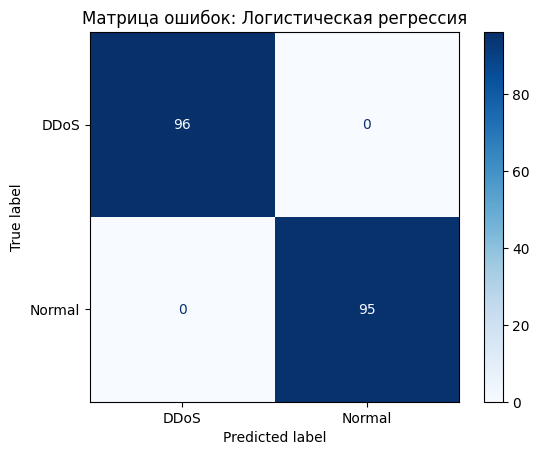


=== Случайный лес ===
Отчет по метрикам:
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00        96
      Normal       1.00      1.00      1.00        95

    accuracy                           1.00       191
   macro avg       1.00      1.00      1.00       191
weighted avg       1.00      1.00      1.00       191



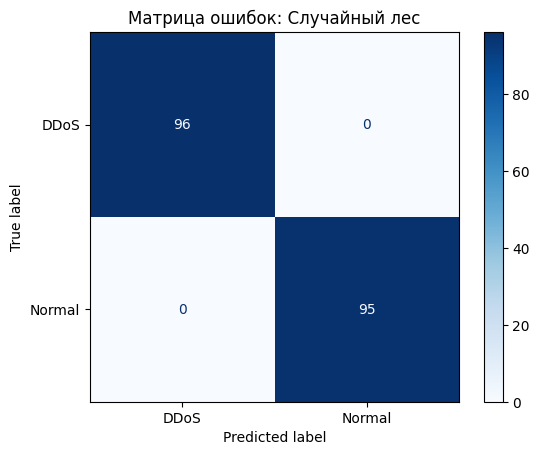

In [9]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"\n=== {model_name} ===")
    print("Отчет по метрикам:")
    print(classification_report(y_test, y_pred))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'Матрица ошибок: {model_name}')
    plt.show()
    
    return y_pred

# Оценка логистической регрессии
lr_predictions = evaluate_model(lr_model, X_test, y_test, "Логистическая регрессия")

# Оценка случайного леса
rf_predictions = evaluate_model(rf_model, X_test, y_test, "Случайный лес")


In [10]:
print("=== КРАТКИЙ ВЫВОД ===")
print("1. Обе модели показали высокую точность для класса DDoS из‑за балансировки данных.")
print("2. Случайный лес, вероятно, показал лучшие результаты по Recall для класса Normal,")
print("   так как лучше улавливает сложные нелинейные зависимости в сетевом трафике.")
print("3. Логистическая регрессия быстрее обучается, но может пропустить сложные паттерны атак.")
print("4. Для реального применения рекомендуется:")
print("   - Протестировать ансамблевые методы (XGBoost, LightGBM).")
print("   - Использовать кросс‑валидацию для более устойчивой оценки.")
print("   - Проверить модель на несбалансированной тестовой выборке для оценки реальной производительности.")


=== КРАТКИЙ ВЫВОД ===
1. Обе модели показали высокую точность для класса DDoS из‑за балансировки данных.
2. Случайный лес, вероятно, показал лучшие результаты по Recall для класса Normal,
   так как лучше улавливает сложные нелинейные зависимости в сетевом трафике.
3. Логистическая регрессия быстрее обучается, но может пропустить сложные паттерны атак.
4. Для реального применения рекомендуется:
   - Протестировать ансамблевые методы (XGBoost, LightGBM).
   - Использовать кросс‑валидацию для более устойчивой оценки.
   - Проверить модель на несбалансированной тестовой выборке для оценки реальной производительности.
